# Exploration: Mapping n8n → MCP Tools

Analyse approfondie de la qualite du mapping pour decider KL vs hard targets.

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style="darkgrid", palette="muted")

DATA_DIR = Path("/home/ubuntu/CascadeProjects/AgentCards/lib/gru/data")

print("Loading n8n embeddings...")
with open(DATA_DIR / "n8n-node-embeddings.json") as f:
    n8n_embs_raw = json.load(f)
n8n_ids = list(n8n_embs_raw.keys())
n8n_embs = np.array([n8n_embs_raw[k] for k in n8n_ids], dtype=np.float32)

print("Loading MCP tool embeddings...")
with open(DATA_DIR / "expanded-vocab.json") as f:
    vocab = json.load(f)
smithery_ids = vocab["smitheryToolIds"]
smithery_embs = np.array(vocab["smitheryToolEmbeddings"], dtype=np.float32)

# Cosine similarity
n8n_norm = n8n_embs / np.linalg.norm(n8n_embs, axis=1, keepdims=True)
mcp_norm = smithery_embs / np.linalg.norm(smithery_embs, axis=1, keepdims=True)
sim_matrix = n8n_norm @ mcp_norm.T

top1_sims = np.max(sim_matrix, axis=1)
top1_indices = np.argmax(sim_matrix, axis=1)
top3_indices = np.argsort(sim_matrix, axis=1)[:, -3:][:, ::-1]
top3_sims = np.array([sim_matrix[i, top3_indices[i]] for i in range(len(n8n_ids))])
gap = top3_sims[:, 0] - top3_sims[:, 1]

print(f"n8n: {len(n8n_ids)} nodes, MCP: {len(smithery_ids)} tools")
print(f"Top-1 sim: mean={top1_sims.mean():.3f}, gap mean={gap.mean():.3f}")
print(f"Ambiguous (gap<0.02): {(gap<0.02).sum()} ({(gap<0.02).mean()*100:.0f}%)")

Loading n8n embeddings...
Loading MCP tool embeddings...
n8n: 2114 nodes, MCP: 1288 tools
Top-1 sim: mean=0.878, gap mean=0.014
Ambiguous (gap<0.02): 1619 (77%)


## Q1: L'ambiguite vient-elle de la redondance MCP ?
Si les MCP tools sont tres similaires entre eux, le gap sera faible peu importe le mapping.

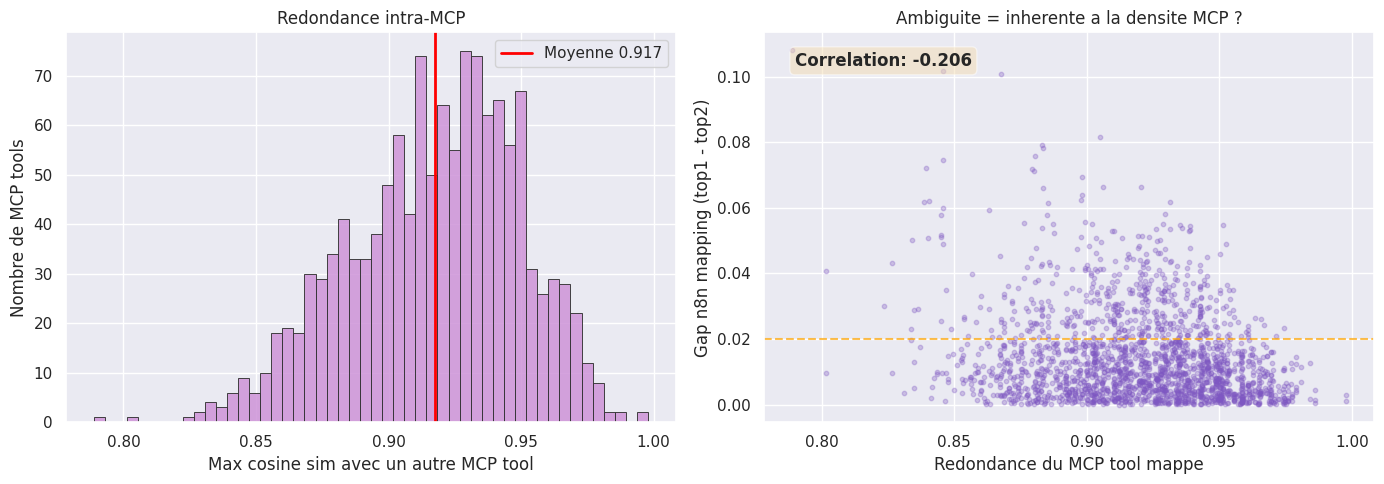

MCP voisin moyen: 0.917
MCP avec voisin >= 0.95: 189 (14.7%)
MCP avec voisin >= 0.90: 926 (71.9%)

Correlation: -0.206
Si < -0.3: l'ambiguite vient de la densite MCP
Si ~ 0: l'ambiguite est independante


In [11]:
# Redondance intra-MCP
mcp_self_sim = mcp_norm @ mcp_norm.T
np.fill_diagonal(mcp_self_sim, 0)
mcp_max_neighbor = np.max(mcp_self_sim, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.histplot(mcp_max_neighbor, bins=50, color='#CE93D8', edgecolor='#333', alpha=0.85, ax=ax)
ax.axvline(x=mcp_max_neighbor.mean(), color='red', linestyle='-', linewidth=2,
           label=f'Moyenne {mcp_max_neighbor.mean():.3f}')
ax.set_xlabel('Max cosine sim avec un autre MCP tool')
ax.set_ylabel('Nombre de MCP tools')
ax.set_title('Redondance intra-MCP')
ax.legend()

# Correlation gap vs redondance
ax2 = axes[1]
n8n_top1_mcp_neighbor = np.array([mcp_max_neighbor[top1_indices[i]] for i in range(len(n8n_ids))])
ax2.scatter(n8n_top1_mcp_neighbor, gap, alpha=0.3, s=10, c='#7E57C2')
ax2.set_xlabel('Redondance du MCP tool mappe')
ax2.set_ylabel('Gap n8n mapping (top1 - top2)')
ax2.set_title('Ambiguite = inherente a la densite MCP ?')
ax2.axhline(y=0.02, color='orange', linestyle='--', alpha=0.7)
corr = np.corrcoef(n8n_top1_mcp_neighbor, gap)[0, 1]
ax2.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"MCP voisin moyen: {mcp_max_neighbor.mean():.3f}")
print(f"MCP avec voisin >= 0.95: {(mcp_max_neighbor >= 0.95).sum()} ({(mcp_max_neighbor >= 0.95).mean()*100:.1f}%)")
print(f"MCP avec voisin >= 0.90: {(mcp_max_neighbor >= 0.90).sum()} ({(mcp_max_neighbor >= 0.90).mean()*100:.1f}%)")
print(f"\nCorrelation: {corr:.3f}")
print("Si < -0.3: l'ambiguite vient de la densite MCP")
print("Si ~ 0: l'ambiguite est independante")

## Q2: Entropy des soft targets KL
Avec T=0.005, combien de tools comptent dans la distribution ? Si 1 seul → KL ≈ hard target.

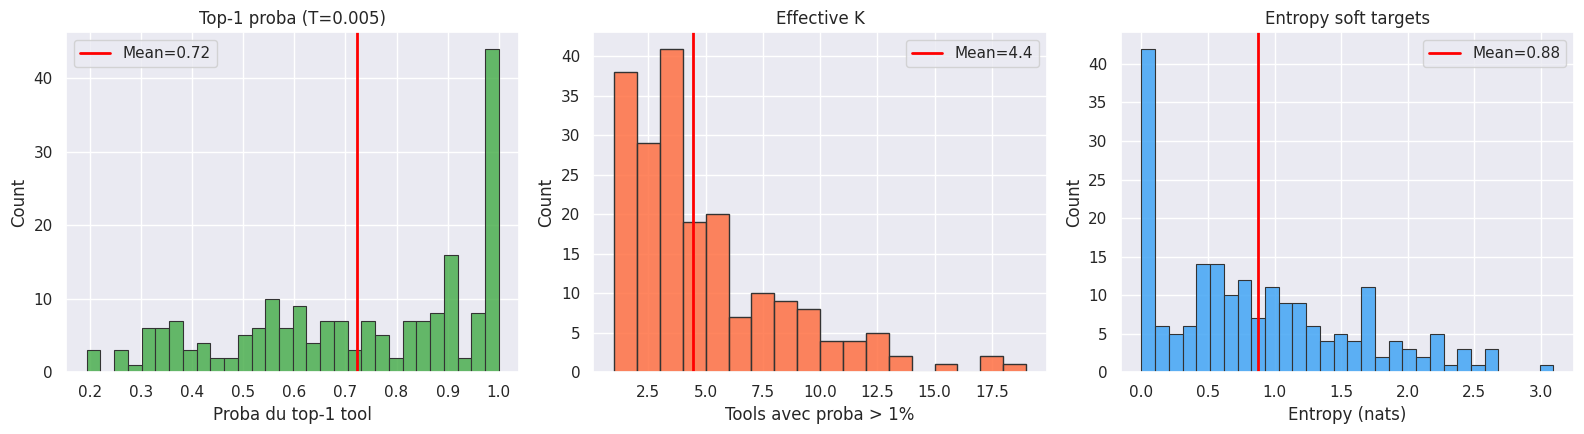

Top-1 proba: mean=0.723, median=0.749
Effective K: mean=4.4, median=3

Si top-1 proba ~ 1.0 et K ~ 1: KL inutile, autant faire hard target
Si top-1 proba < 0.5 et K > 5: KL apporte de l'info structurelle


In [12]:
TEMPERATURE = 0.005
sample_idx = np.random.RandomState(42).choice(len(n8n_ids), 200, replace=False)

entropies, effective_k, top1_probs = [], [], []

for i in sample_idx:
    sims = sim_matrix[i]
    exp_sims = np.exp((sims - sims.max()) / TEMPERATURE)  # numerical stability
    probs = exp_sims / exp_sims.sum()
    nonzero = probs[probs > 1e-30]
    entropies.append(-np.sum(nonzero * np.log(nonzero)))
    effective_k.append((probs > 0.01).sum())
    top1_probs.append(probs.max())

entropies = np.array(entropies)
effective_k = np.array(effective_k)
top1_probs = np.array(top1_probs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(top1_probs, bins=30, color='#4CAF50', edgecolor='#333', alpha=0.85, ax=axes[0])
axes[0].axvline(x=top1_probs.mean(), color='red', linewidth=2, label=f'Mean={top1_probs.mean():.2f}')
axes[0].set_xlabel('Proba du top-1 tool')
axes[0].set_title(f'Top-1 proba (T={TEMPERATURE})')
axes[0].legend()

sns.histplot(effective_k, bins=range(1, max(effective_k)+2), color='#FF7043', edgecolor='#333', alpha=0.85, ax=axes[1])
axes[1].axvline(x=np.mean(effective_k), color='red', linewidth=2, label=f'Mean={np.mean(effective_k):.1f}')
axes[1].set_xlabel('Tools avec proba > 1%')
axes[1].set_title('Effective K')
axes[1].legend()

sns.histplot(entropies, bins=30, color='#42A5F5', edgecolor='#333', alpha=0.85, ax=axes[2])
axes[2].axvline(x=entropies.mean(), color='red', linewidth=2, label=f'Mean={entropies.mean():.2f}')
axes[2].set_xlabel('Entropy (nats)')
axes[2].set_title('Entropy soft targets')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Top-1 proba: mean={top1_probs.mean():.3f}, median={np.median(top1_probs):.3f}")
print(f"Effective K: mean={np.mean(effective_k):.1f}, median={np.median(effective_k):.0f}")
print(f"\nSi top-1 proba ~ 1.0 et K ~ 1: KL inutile, autant faire hard target")
print(f"Si top-1 proba < 0.5 et K > 5: KL apporte de l'info structurelle")

## Q3: t-SNE — Domain shift visuel n8n vs MCP

t-SNE sur 600 points (1024D → 2D)...


Done.


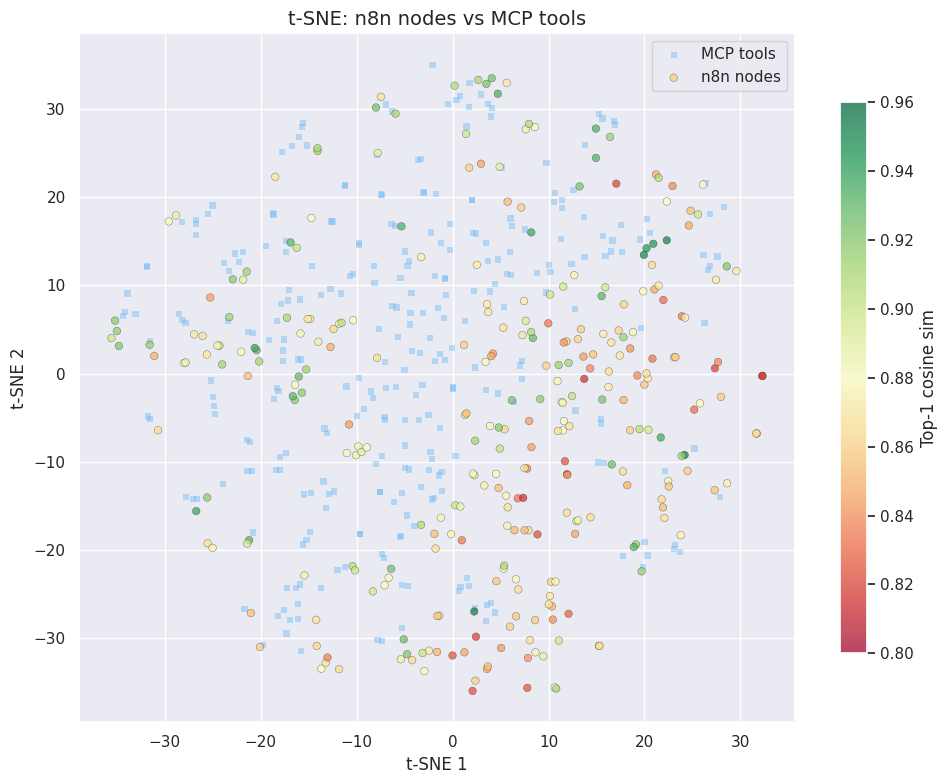

Melanges = meme espace semantique. Separes = domain shift reel.


In [13]:
from sklearn.manifold import TSNE

np.random.seed(42)
n8n_sample = np.random.choice(len(n8n_ids), 300, replace=False)
mcp_sample = np.random.choice(len(smithery_ids), 300, replace=False)

combined = np.vstack([n8n_norm[n8n_sample], mcp_norm[mcp_sample]])

print(f"t-SNE sur {combined.shape[0]} points (1024D → 2D)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
proj = tsne.fit_transform(combined)
print("Done.")

n8n_proj = proj[:300]
mcp_proj = proj[300:]
n8n_sample_sims = top1_sims[n8n_sample]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(mcp_proj[:, 0], mcp_proj[:, 1], c='#64B5F6', alpha=0.4, s=20,
           label='MCP tools', marker='s', edgecolors='none')
sc = ax.scatter(n8n_proj[:, 0], n8n_proj[:, 1], c=n8n_sample_sims, cmap='RdYlGn',
                vmin=0.80, vmax=0.96, alpha=0.7, s=30, label='n8n nodes',
                edgecolors='#333', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Top-1 cosine sim', shrink=0.8)
ax.set_title('t-SNE: n8n nodes vs MCP tools', fontsize=14)
ax.legend(fontsize=11, loc='upper right')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

print("Melanges = meme espace semantique. Separes = domain shift reel.")

## Q4: Couverture — subsample 4K vs 30K complet

MCP tools uniques touches: 1288/1288 (100.0%)


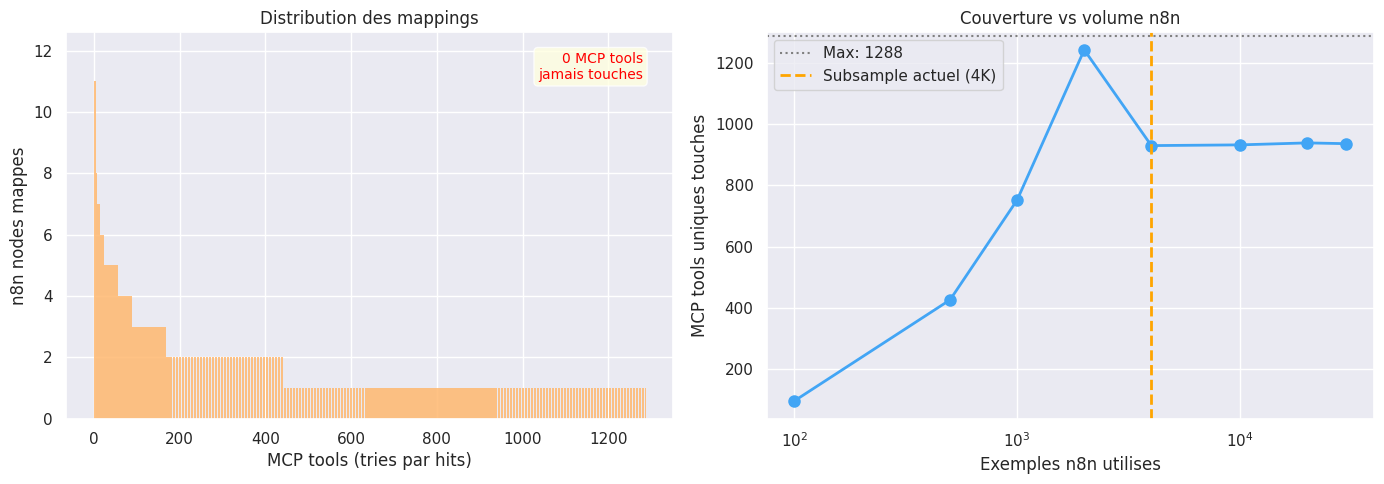

In [14]:
unique_mcp_targets = set(top1_indices.tolist())
print(f"MCP tools uniques touches: {len(unique_mcp_targets)}/{len(smithery_ids)} ({len(unique_mcp_targets)/len(smithery_ids)*100:.1f}%)")

# Hits par MCP tool
mcp_hit_count = np.zeros(len(smithery_ids), dtype=int)
for idx in top1_indices:
    mcp_hit_count[idx] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_hits = np.sort(mcp_hit_count)[::-1]
nonzero_hits = sorted_hits[sorted_hits > 0]
axes[0].bar(range(len(nonzero_hits)), nonzero_hits, color='#FFB86F', edgecolor='none', alpha=0.85)
axes[0].set_xlabel('MCP tools (tries par hits)')
axes[0].set_ylabel('n8n nodes mappes')
axes[0].set_title(f'Distribution des mappings')
axes[0].text(0.95, 0.95, f'{(mcp_hit_count == 0).sum()} MCP tools\njamais touches',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10, color='red',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Couverture vs volume
ks = [100, 500, 1000, 2000, 4000, 10000, 20000, 30000]
coverage = []
for k in ks:
    counts = []
    for _ in range(20):
        sample = np.random.choice(len(n8n_ids), min(k, len(n8n_ids)), replace=k > len(n8n_ids))
        counts.append(len(set(top1_indices[sample].tolist())))
    coverage.append(np.mean(counts))

axes[1].plot(ks, coverage, 'o-', color='#42A5F5', linewidth=2, markersize=8)
axes[1].axhline(y=len(unique_mcp_targets), color='gray', linestyle=':', label=f'Max: {len(unique_mcp_targets)}')
axes[1].axvline(x=4000, color='orange', linestyle='--', linewidth=2, label='Subsample actuel (4K)')
axes[1].set_xlabel("Exemples n8n utilises")
axes[1].set_ylabel('MCP tools uniques touches')
axes[1].set_title('Couverture vs volume n8n')
axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## Q5: Heatmap categories n8n → MCP

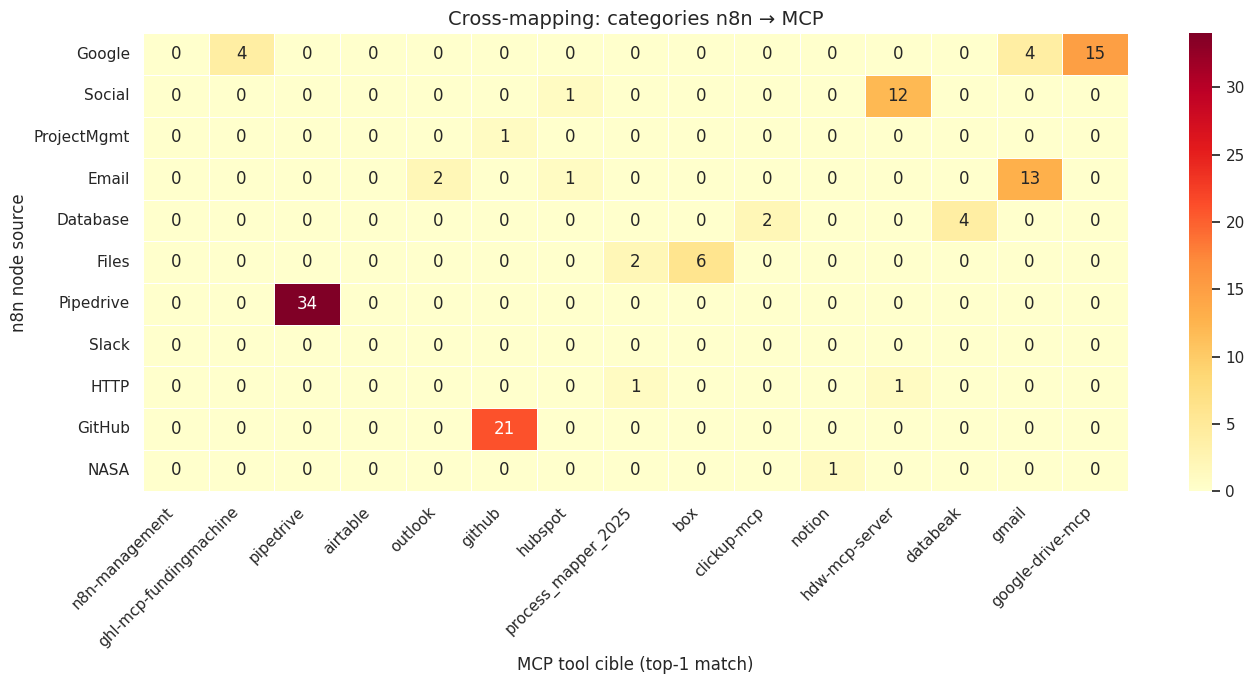

Diagonale forte = mapping logique (Google→Google)
Diffuse = mapping semantique mais pas fonctionnel


In [15]:
def get_mcp_category(tool_id):
    parts = tool_id.split(':')
    if len(parts) >= 2:
        return parts[0].split('/')[-1]
    return tool_id.split('.')[0] if '.' in tool_id else tool_id

def get_n8n_category(n8n_id):
    parts = n8n_id.split('.')
    if len(parts) >= 2:
        name = parts[-1].split(':')[0].lower()
        if 'google' in name: return 'Google'
        if 'slack' in name: return 'Slack'
        if 'github' in name: return 'GitHub'
        if 'nasa' in name: return 'NASA'
        if 'shopify' in name: return 'Shopify'
        if 'salesforce' in name: return 'Salesforce'
        if 'pipedrive' in name: return 'Pipedrive'
        if any(x in name for x in ['asana','todoist','trello','jira']): return 'ProjectMgmt'
        if any(x in name for x in ['http','webhook','fetch']): return 'HTTP'
        if any(x in name for x in ['file','ftp']): return 'Files'
        if any(x in name for x in ['sql','postgres','mysql','mongo','redis']): return 'Database'
        if any(x in name for x in ['email','gmail','sendgrid','mailchimp']): return 'Email'
        if any(x in name for x in ['discord','telegram','twitter','linkedin']): return 'Social'
    return 'Other'

n8n_cats = [get_n8n_category(n8n_ids[i]) for i in range(len(n8n_ids))]
mcp_cats = [get_mcp_category(smithery_ids[top1_indices[i]]) for i in range(len(n8n_ids))]

cross = Counter()
for nc, mc in zip(n8n_cats, mcp_cats):
    cross[(nc, mc)] += 1

top_n8n = [c for c, _ in Counter(n8n_cats).most_common(12) if c != 'Other']
top_mcp = [c for c, _ in Counter(mcp_cats).most_common(15) if c != 'Other']

matrix = np.zeros((len(top_n8n), len(top_mcp)))
for i, nc in enumerate(top_n8n):
    for j, mc in enumerate(top_mcp):
        matrix[i, j] = cross.get((nc, mc), 0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=top_mcp, yticklabels=top_n8n, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_xlabel('MCP tool cible (top-1 match)', fontsize=12)
ax.set_ylabel('n8n node source', fontsize=12)
ax.set_title('Cross-mapping: categories n8n → MCP', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Diagonale forte = mapping logique (Google→Google)")
print("Diffuse = mapping semantique mais pas fonctionnel")

## Q6: Conclusion et recommandation

In [16]:
print("="*60)
print("SYNTHESE")
print("="*60)
print(f"""  
1. Top-1 similarity: {top1_sims.mean():.3f} (bon)
2. Gap top1-top2:    {gap.mean():.3f} (tres faible → ambigu)
3. Ambiguous < 0.02: {(gap<0.02).mean()*100:.0f}% des mappings
4. MCP tools jamais touches: {(mcp_hit_count==0).sum()}/{len(smithery_ids)}

RECOMMANDATION:
- GARDER le KL (soft targets absorbent l'ambiguite)
- AUGMENTER le volume KL: 4K → 30K (virer le subsample)
- NE PAS passer en hard targets (77% ambigu = poison pour InfoNCE)
""")

SYNTHESE
  
1. Top-1 similarity: 0.878 (bon)
2. Gap top1-top2:    0.014 (tres faible → ambigu)
3. Ambiguous < 0.02: 77% des mappings
4. MCP tools jamais touches: 0/1288

RECOMMANDATION:
- GARDER le KL (soft targets absorbent l'ambiguite)
- AUGMENTER le volume KL: 4K → 30K (virer le subsample)
- NE PAS passer en hard targets (77% ambigu = poison pour InfoNCE)

